__Markus Mulvihill__

__Last updated March 2026__

# Necessary Packages and Modules

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Introduction

This file examines the accuracy and time complexity of the extended Kalman filter and the particle filter with various number of particles.

# Setup
## Patient Cohort
+ 100 patients
+ Simulation over 60 hours
+ Initial $BG$ (mmol/L) is chosen from a log normal distribution of $\mu = 7.6$ and $\sigma=1.3$
+ Initial $Q$ and $I$ is 15 mu/L
+ Inital $P1$ and $P2$ is assumed to be 0 mmol/L
+ $\,SI$ for the patients is constant at $2 \cdot 10^{-4}$
+ $u_{ex}(t) = 75 \cdot e^{-\left(\frac{\log(2)}{300}\right) \cdot \left((t + 120) \mod (300)\right)}$ (mU/min)
+ $\,PN(t) = e^{-\left(\frac{\log(2)}{300}\right) \cdot \left(t \mod (300)\right)}$ (mmol/min)
+ $D(t) = 0.24$ (mmol/min)
+ True dynamics are derived from the ICING model with time steps $\,dt=1$ min
+ Blood Glucose measurements occur every 2 hours that contain Gaussian measurement noise $N(0,0.25^2)$

## State Estimators
+ State Variables are $\dot{\,BG}$, $\dot{Q}$, $\dot{I}$, $\dot{\,P1}$, $\dot{\,P2}$, $u_{en}$, $\,SI$ 
+ The initial states for all patients are assigned as $\begin{bmatrix} 7.6 & 15 & 15 & 0 & 0 & k_1 e^{-\frac{k_2}{k_3}15} & 2.1 \cdot 10^{-4} \end{bmatrix}$
+ Process Noise is $\text{diag} \left( \begin{bmatrix} \frac{1e^{-4}}{120} & \frac{1e^{-4}}{120} & \frac{1e^{-4}}{120} & \frac{1e^{-4}}{120} & \frac{1e^{-4}}{120} & 0 & \frac{1e^{-12}}{120} \end{bmatrix} \right)$
+ Initial states for each particle is sampled from a Gaussian distribution with a mean of the initial state and variance of the process noise

# Experiment
+ The time to run the state estimator and the accuracy of the $BG$ estimate will be saved
+ Particle Filters of sizes $N = \begin{bmatrix}  100 & 200 & 300 & 400 & 500 & 1000 & 1500 & 3000 & 5000 \end{bmatrix}$ will be used

In [35]:
try:
    time_train = np.load("../scripts/variables/time_arr_02.npy")
    error_est = np.load("../scripts/variables/error_arr_02.npy")
except Exception:
    print("Can not find results from 02_Estimator_Comparison_script.py file")

# Plot Results

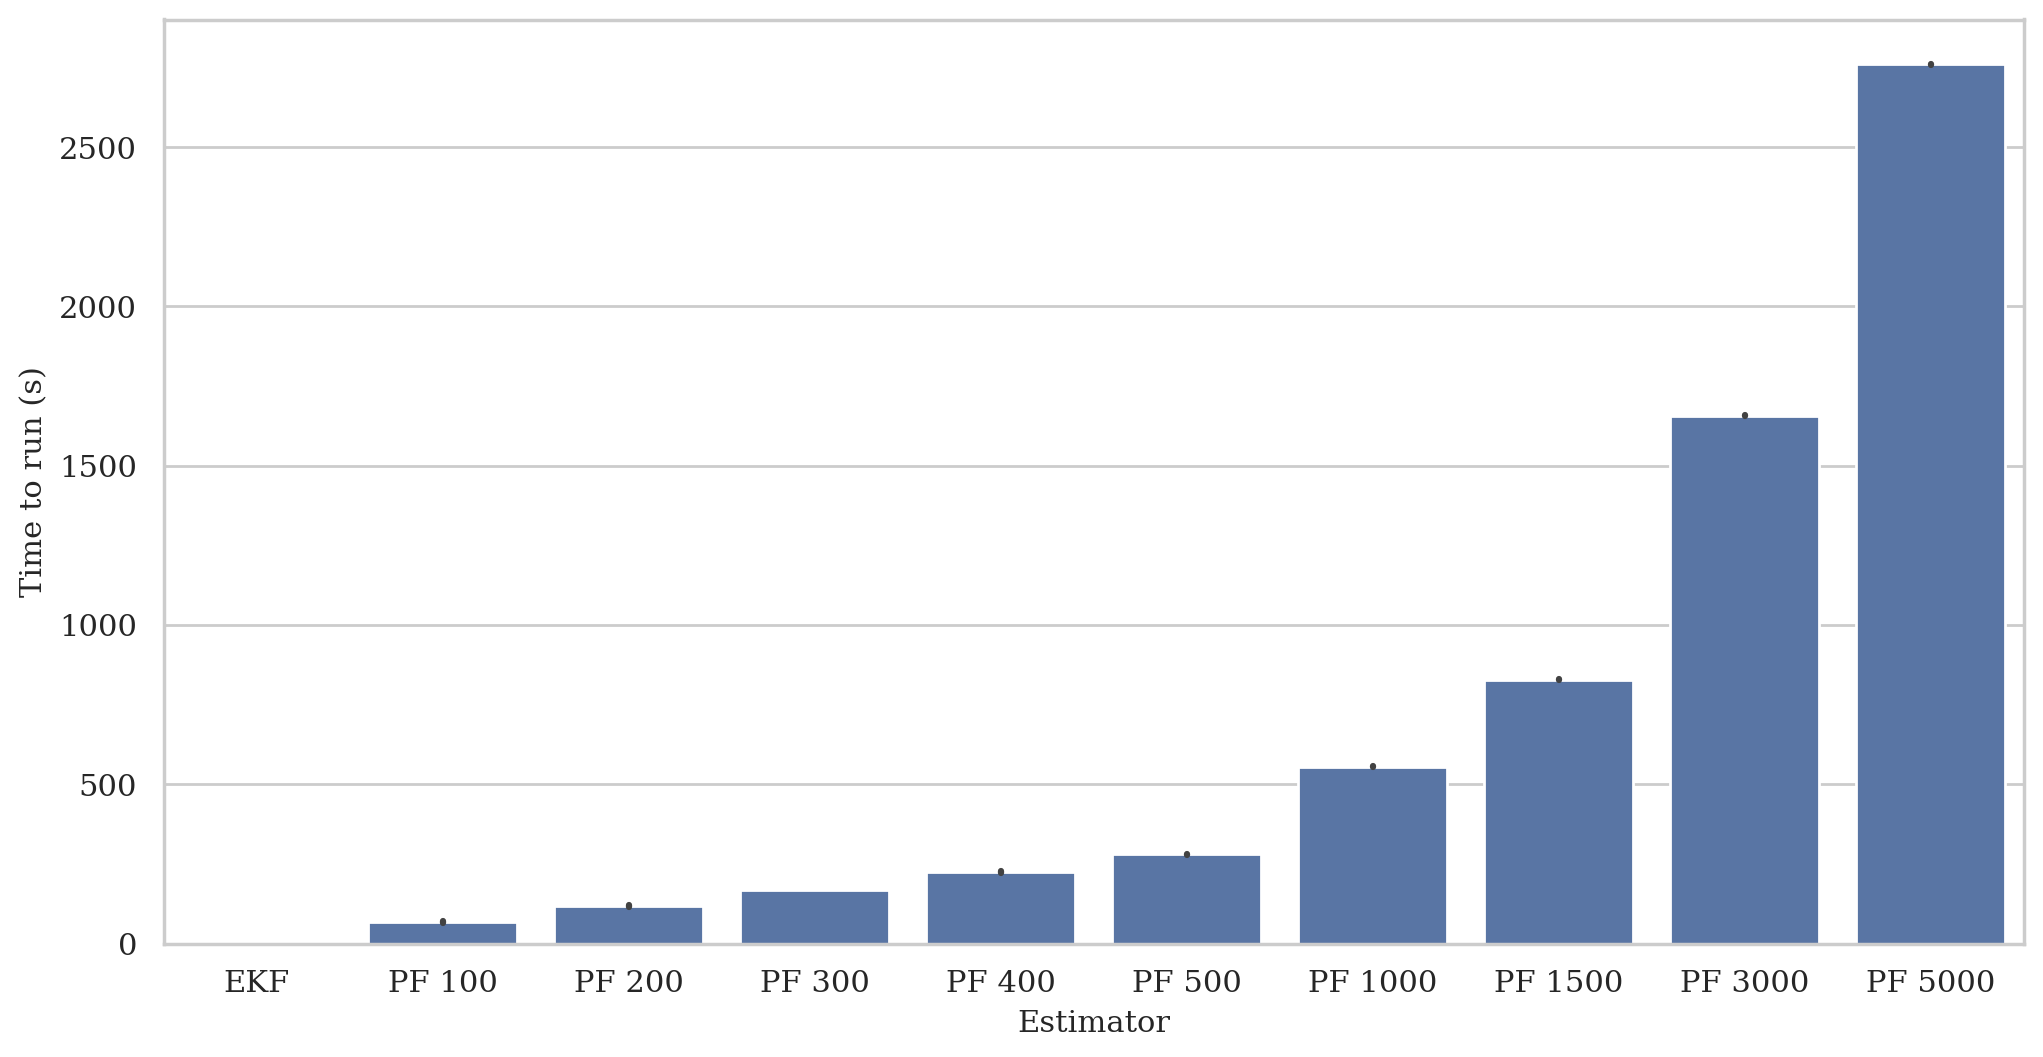

In [47]:
filters = ["EKF"]
num_particles = np.asarray([100, 200, 300, 400, 500, 1000, 1500, 3000, 5000])
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
df = pd.DataFrame(time_train.T, columns=filters).melt(var_name='Estimator', value_name='Time to run (s)')

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(df, x="Estimator", y="Time to run (s)", ax=ax);

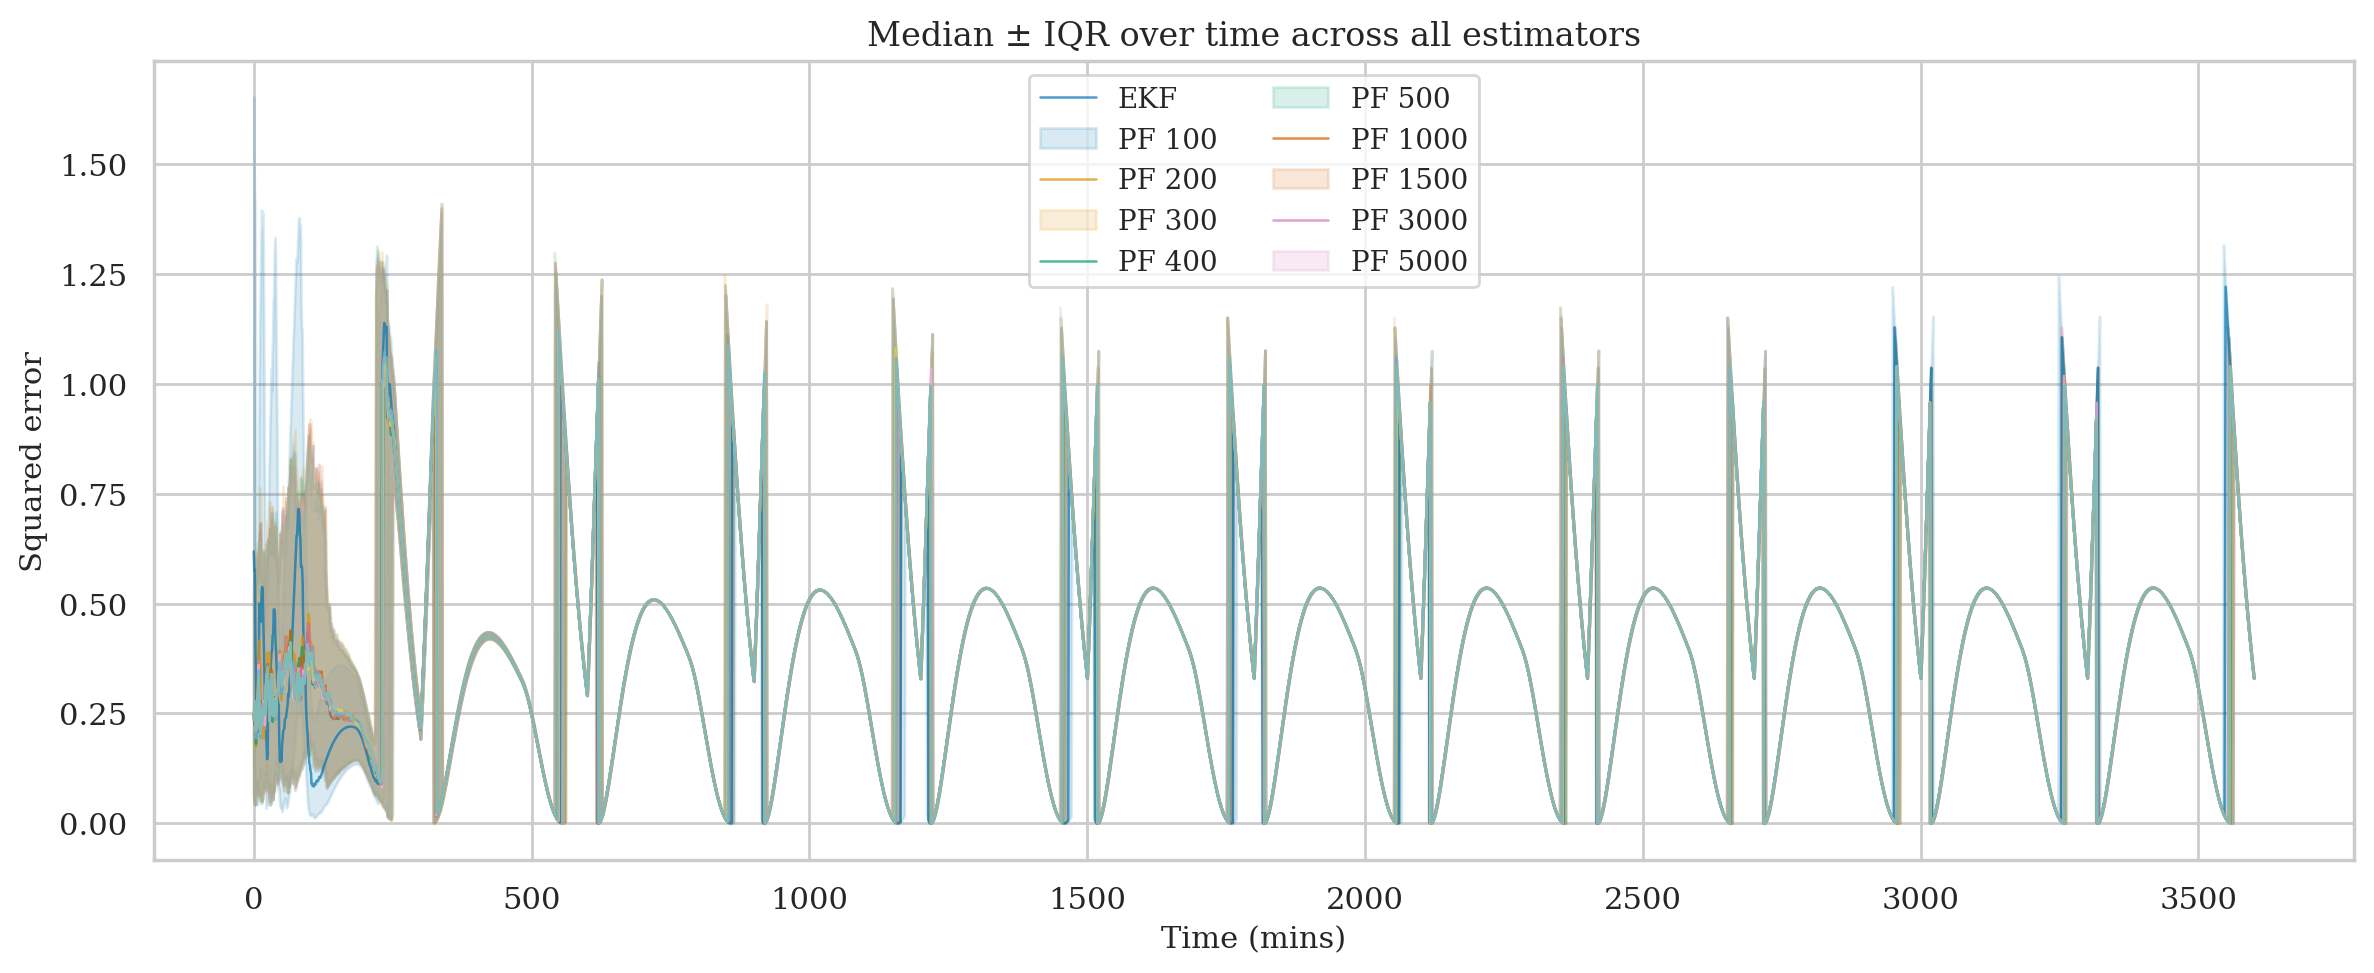

In [64]:
squared_error_est = error_est**2
median = np.median(squared_error_est, axis=1)   
p25 = np.percentile(squared_error_est, 25, axis=1)
p75 = np.percentile(squared_error_est, 75, axis=1)
time = np.arange(median.shape[1])
palette = sns.color_palette("colorblind", len(filters))

fig, ax = plt.subplots(figsize=(12,5))

for i in range(len(filters)):
    ax.plot(time, median[i], color=palette[i], linewidth=0.9, alpha=0.7)
    ax.fill_between(time, p25[i], p75[i], color=palette[i], alpha=0.15)
ax.set_xlabel('Time (mins)')
ax.set_ylabel('Squared error')
ax.set_title('Median ± IQR over time across all estimators')
ax.legend(filters, ncols=2, loc='best')
plt.tight_layout()
plt.show();